# Semana 4 - Adequação do modelo e modelos não lineares

Nenhum aficionado de fritas gosta que fiquem encharcadas, por isso é importante encontrar características do processo de produção que as produzam com uma textura atraente. 
Os seguintes dados em que x=tempo de fritura (s) e y= teor de umidade (%) apareceram no artigo “Thermal and Physical Properties of Tortilla Chips as a Function of Frying Time” (J. of Food Processing and Preservation, 1995: 175–189).


a.   Construa um gráfico de dispersão de y versus x e comente.

b.   Construa um gráfico de dispersão dos pares (ln(x), ln(y)) e comente.

c.   Qual é a relação probabilística entre x e y sugerido pelo padrão linear no gráfico da parte (b)?

d.   Preveja o valor do teor de umidade ao fritar as batatas por 20s, de uma forma que transmite informações sobre confiabilidade e precisão.

e.   Analise os resíduos do ajuste do modelo de regressão linear para os dados transformados e comente.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels.api as sm
import numpy as np


In [10]:
lstx = (5, 10, 15, 20, 25, 30, 45, 60)
lsty= (16.3, 9.7, 8.1, 4.2, 3.4, 2.9, 1.9, 1.3)
# Construir o DataFrame e nomear as colunas
dfries = pd.DataFrame(list(zip(lstx, lsty)),
               columns =["x","y"])
x=dfries['x']
y=dfries['y']
dfries.head()

,x,y
0,5,16.3
1,10,9.7
2,15,8.1
3,20,4.2
4,25,3.4


## Resposta a

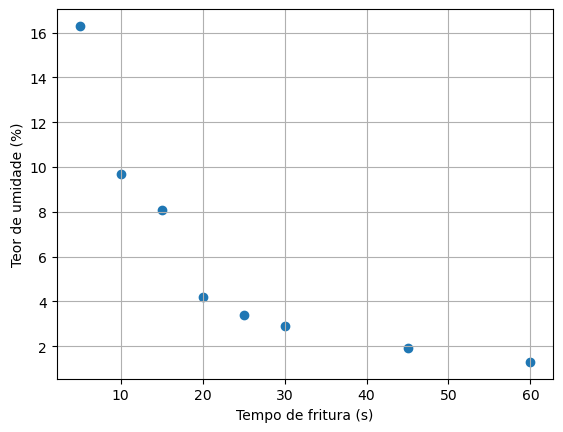

In [11]:

# Gráfico de dispersão
#plt.rcParams.update({'figure.figsize':(8,6), 'figure.dpi':100})
plt.scatter(dfries['x'],dfries['y'])
plt.xlabel('Tempo de fritura (s)');
plt.ylabel('Teor de umidade (%)')
plt.grid(True)
plt.show()

In [12]:
#adicionar uma constante preditora
x = sm.add_constant(x)
#fit linear regression model
modelo = sm.OLS(y, x).fit() #atenção esta variável será usada no IC
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     11.48
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0147
Time:                        12:20:35   Log-Likelihood:                -19.587
No. Observations:                   8   AIC:                             43.17
Df Residuals:                       6   BIC:                             43.33
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.8599      2.079      5.705      0.0

## Reposta b

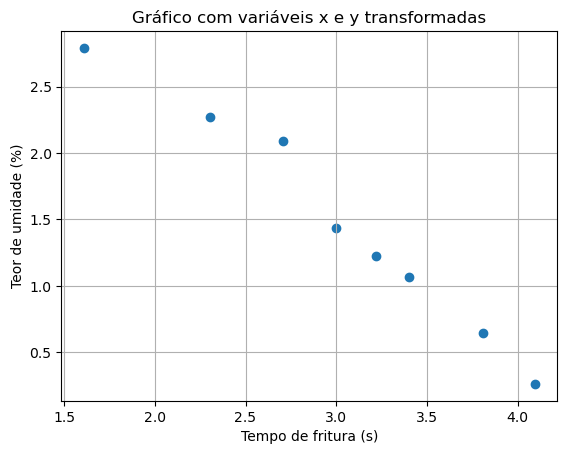

In [15]:

x=dfries['x']
y=dfries['y']
vtx=np.log(x)
vty=np.log(y)
plt.scatter(vtx,vty)
plt.xlabel('Tempo de fritura (s)');
plt.ylabel('Teor de umidade (%)')
plt.title('Gráfico com variáveis x e y transformadas')
plt.grid(True)
plt.show()

In [14]:
dfries2 = pd.DataFrame(list(zip(x, y, vtx, vty)),
               columns =["x","y","ln_x","ln_y"])
dfries2.head()

,x,y,ln_x,ln_y
0,5,16.3,1.609438,2.791165
1,10,9.7,2.302585,2.272126
2,15,8.1,2.708050,2.091864
3,20,4.2,2.995732,1.435085
4,25,3.4,3.218876,1.223775


## Resposta c

In [16]:

#adicionar uma constante preditora
vtx = sm.add_constant(vtx)
#fit linear regression model
modelo = sm.OLS(vty, vtx).fit() #atenção esta variável será usada no IC
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.971
Method:                 Least Squares   F-statistic:                     239.1
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           4.63e-06
Time:                        12:21:10   Log-Likelihood:                 5.2525
No. Observations:                   8   AIC:                            -6.505
Df Residuals:                       6   BIC:                            -6.346
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6384      0.211     21.978      0.0

In [18]:
# parâmetros da reta
b=modelo.params
b

const    4.638415
x       -1.049198
dtype: float64

In [25]:
# parâmetros da reta
b=modelo.params
b0=b.const #intercepto
b1=b.x #inclinação
print(f'y = {b0:.3f} {b1:+.3f} x')

y = 4.638 -1.049 x


In [35]:
from numpy.core.fromnumeric import mean

C:\Users\Amanda Rodrigues\AppData\Local\Temp\ipykernel_21756\3383920318.py:1: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.mean.
  from numpy.core.fromnumeric import mean


## Resposta d

In [27]:
#usar a tabela tstudent pata t
from scipy.stats import t
alpha = 0.05  # nível de significia = 5% 
df = len(x) - 2 # gl (n - 2)                                     
v = t.ppf(1 - alpha/2, df) 
print(f't=: {v}') 

t=: 2.4469118511449786


Uma fórmula alternativa de SQE é

$SQE=∑(y_i - \hat{y}_i)$

$s^2=\frac{SQE}{n-2}$

$s=\sqrt(s^2)$

e $s_{\hat{Y}}=s\sqrt(\frac{1}{n}+\frac{(x^* -\bar{x})^2}{S_{XX}})$


In [29]:
x = dfries['x']
y = dfries['y']
vtx = np.log(x)
vty = np.log(y)
y_pred = list(modelo.predict())
resi = modelo.resid

# SQE = residuos ao quadrado
sqe = np.sum(resi * resi)
gl = modelo.df_resid  # gl = n-2
s2 = sqe / gl
s = np.sqrt(s2)

print("=" * 50)
print("📊 ANÁLISE DE RESÍDUOS")
print("=" * 50)
print(f"Soma dos Quadrados dos Erros (SQE): {sqe:.6f}")
print(f"Graus de Liberdade (gl): {gl}")
print(f"Variância Residual (s²): {s2:.6f}")
print(f"Erro Padrão Residual (s): {s:.6f}")
print("=" * 50)

📊 ANÁLISE DE RESÍDUOS
Soma dos Quadrados dos Erros (SQE): 0.125989
Graus de Liberdade (gl): 6.0
Variância Residual (s²): 0.020998
Erro Padrão Residual (s): 0.144908


In [30]:
vtxs=np.log(20) #x*=ln(20)
vtxm=vtx.mean()
n=modelo.df_resid + 2 #gl+2=n
xx=np.sum(vtx*vtx)
xau=np.sum(vtx)
sxx=xx-xau*xau/n
sy=s*pow(((1/n)+(vtxs-vtxm)*(vtxs-vtxm)/sxx),1/2)
sy


np.float64(0.05125314354652712)

In [31]:
#valor esperado de y para x=ln(20)
yln20=b0+b1*vtxs
yln20

np.float64(1.4952982104850645)

In [32]:
sya=pow((s2+sy*sy),1/2)
#IP do valor esperado para um valor específico de x 
IPyln20=([yln20-v*sya,yln20+v*sya])
import math
IPye200=pow(math.e,IPyln20[0])
IPye201=pow(math.e,IPyln20[1])
IPyln20,IPye200,IPye201

([np.float64(1.1191964274867021), np.float64(1.871399993483427)],
 np.float64(3.062392359965259),
 np.float64(6.497386333403843))

## Resposta e

In [33]:

#x=dfries['x']
#y=dfries['y']
#vtx=np.log(x)
#vty=np.log(y)
#y_pred=list(modelo.predict())
##sns.resid(modelo)
resi=list(modelo.resid)
#crear instancia influence
influence = modelo.get_influence()
#obter residuos standardizados
stdresid = list(influence.resid_studentized_internal)
prop=np.divide(resi,stdresid) #e/e* para verificar a proporcionalidade entre o erro e o erro padronizado
dft2 = pd.DataFrame(list(zip(vtx, vty, y_pred, resi, stdresid, prop)),
               columns =["x","y","yc","e","e*","e/e*"])
dft2 

,x,y,yc,e,e*,e/e*
0,1.609438,2.791165,2.949796,-0.158631,-1.649456,0.096171
1,2.302585,2.272126,2.222547,0.049579,0.391681,0.126580
2,2.708050,2.091864,1.797134,0.294730,2.200852,0.133916
3,2.995732,1.435085,1.495298,-0.060214,-0.444247,0.135541
4,3.218876,1.223775,1.261176,-0.037401,-0.277341,0.134855
5,3.401197,1.064711,1.069885,-0.005174,-0.038898,0.133019
6,3.806662,0.641854,0.644472,-0.002618,-0.021025,0.124511
7,4.094345,0.262364,0.342636,-0.080272,-0.703222,0.114149


In [36]:
from statsmodels.graphics.gofplots import ProbPlot

C:\Users\Amanda Rodrigues\AppData\Roaming\Python\Python313\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


Text(0, 0.5, 'Resíduos padronizados')

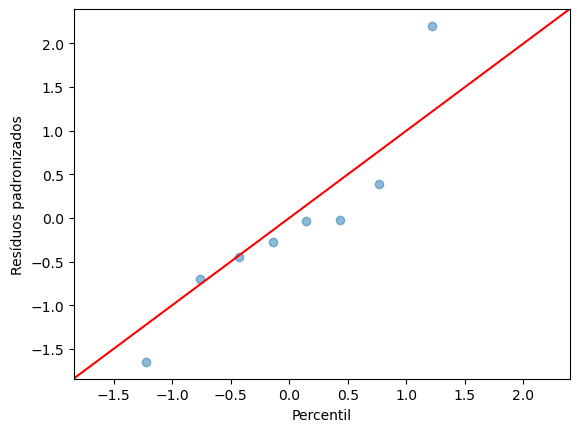

In [37]:
#Gráficos de diagnóstico 5 Probabilidade Normal
QQ = ProbPlot(influence.resid_studentized_internal)
plot_lm_2 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
plot_lm_2.axes[0].set_xlabel('Percentil')
plot_lm_2.axes[0].set_ylabel('Resíduos padronizados')